<a href="https://colab.research.google.com/github/Angor09/sprint7-final-project/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')
plans_copy= plans.copy()
users_copy= users.copy()
usage_copy= usage.copy()

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()/len(users)*100)

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
print(usage.isna().sum()/len(usage)*100)

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Las columnas city y churn_date en el dataset users cuentan con valores nulos del 11.7% y 88.35% respectivamente, con el dataset usage existen valores nulos en las columnas date, duration y length con 0,13%, 55.2% y 44.74% respectivamente  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- en el caso de la columna churn_date podría ignorar el 11.75% que se encuentran como nulos pues son clientes inactivos y adicional verificar si son clientes con diferentes lineas o podrían llegar a ser una potencial oportunidad de cliente
- con la columna city se investigara para confirmar si imputar o dejar como nulos
- En el caso de date se limpiara la columna para confirmar si los valores nulos son datos incorrecto o eliminar en caso de ser necesario
- La columna duration y length se basan en la duracion de la llamada o lo largo del mensaje por lo que es comprensible la cantidad de valores nulos, seran ignorados los valores nulos de ambas columnas

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:

numeric_cols=['user_id','age']
users[numeric_cols].describe()




,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
print(users['age'].median())

47.0


- La columna `user_id` no representa medida real
- La columna `age` cuenta con sentinels -999 como valor minimo

In [ ]:
# explorar columnas numéricas de usage
columnas_usage =['duration','length']
usage[columnas_usage].describe()

,duration,length
count,17924.000000,22104.000000
mean,5.202237,52.127398
std,6.842701,56.611183
min,0.000000,0.000000
25%,1.437500,37.000000
50%,3.500000,50.000000
75%,6.990000,64.000000
max,120.000000,1490.000000


- Las columnas `id` y `user_id` son indicadores, no representan medida real
- Las columnas duration y length por otra parte no parecen contar con errores pero si una gran variacion en length

In [ ]:
# explorar columnas categóricas de users

columnas_user = [ 'city','plan']
users[columnas_user].value_counts()


city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` cuenta con 65 valores '?' y 312 vacios
- La columna `plan` Existen dos tipos de planes 'Basico' y 'Premium'

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna `type` cuenta con dos valores para texto y llamada


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  Valores invalidos en la columna city y sentinels en age
- ¿Qué acción tomarías?  Revisar los valores, confirmar si existe algún motivo al error, al ser un porcentaje bajo se puede tomar diferentes acciones

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users_copy['reg_date'] = pd.to_datetime(users_copy['reg_date'], errors='coerce')

users_copy['reg_date'].isna().sum()

0

In [ ]:
# Convertir a fecha la columna `date` de usage
usage_copy['date'] = pd.to_datetime(usage_copy['date'], errors='coerce')
usage_copy['date'].isna().sum()

50

In [ ]:
# Revisar los años presentes en `reg_date` de users

users_copy['reg_year']= users_copy['reg_date'].dt.year
users_copy['reg_year'].value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_year, dtype: int64

En `reg_date`, existen 40 datos pertenecientes al 2026

In [ ]:
# Revisar los años presentes en `date` de usage
usage_copy['year']= usage_copy['date'].dt.year
usage_copy['year'].describe()


count    39950.0
mean      2024.0
std          0.0
min       2024.0
25%       2024.0
50%       2024.0
75%       2024.0
max       2024.0
Name: year, dtype: float64

En `date`, existen solo valores en el año 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) en users hay 40 datos del 2026, age existen sentinels -999, la comlumna city hay dos valores invalidos y 50 NA en date de usage
- ¿Qué harías con ellas? Revisar columna y sus errores uno por uno para ver errores, determinar el motivo del mismo y tomar medidas de corrección que no afecten la data

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users_copy['age'].median()

users_copy['age'] = users_copy['age'].replace(-999, pd.NA)
users_copy['age'] = users_copy['age'].fillna(age_mediana)


# Verificar cambios
users_copy.describe()

,user_id,age,reg_year
count,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.122250,2023.034000
std,1154.844867,17.690408,0.866044
min,10000.000000,18.000000,2022.000000
25%,10999.750000,33.000000,2022.000000
50%,11999.500000,47.000000,2023.000000
75%,12999.250000,63.000000,2024.000000
max,13999.000000,79.000000,2026.000000


In [ ]:
# Reemplazar ? por NA en city
users_copy['city'] = users_copy['city'].replace('?', pd.NA)

# Verificar cambios
users_copy['city'].isna().sum()

565

In [ ]:
# Marcar fechas futuras como NA para reg_date

limite= pd.to_datetime('2025-01-01')
users_copy.loc[users_copy['reg_date'] > limite,'reg_date' ]= pd.NaT


# Verificar cambios
users_copy['reg_date'].describe()
users_copy['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration



mar_dur = usage_copy['duration'].isna().groupby(usage_copy['type']).mean().sort_values() *100





print(mar_dur.round(2))

type
call     0.00
text    99.93
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length


mar_len = usage_copy['length'].isna().groupby(usage_copy['type']).mean().sort_values(ascending=False) *100


print(mar_len.round(2))



type
call    99.93
text     0.00
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` dependen de la columna type, si es una llamada la columna length es Na y viceversa

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage_copy["is_text"] = (usage_copy["type"] == "text").astype(int) #conocer el total de mensajes
usage_copy["is_call"] = (usage_copy["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage_copy.groupby(usage_copy['user_id']).agg(
    cant_mensajes=('is_text','sum'),
    cant_llamadas=('is_call','sum'),
    cant_minutos_llamada=('duration','sum')
)


# observar resultado
usage_agg.head(3)


,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74


In [ ]:
# Renombrar columnas

# observar resultado

In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users_copy.merge(usage_agg, on='user_id',how='left')
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
num_cols=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[num_cols].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
dist_pct= user_profile['plan'].value_counts(normalize=True)*100
dist_pct.round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

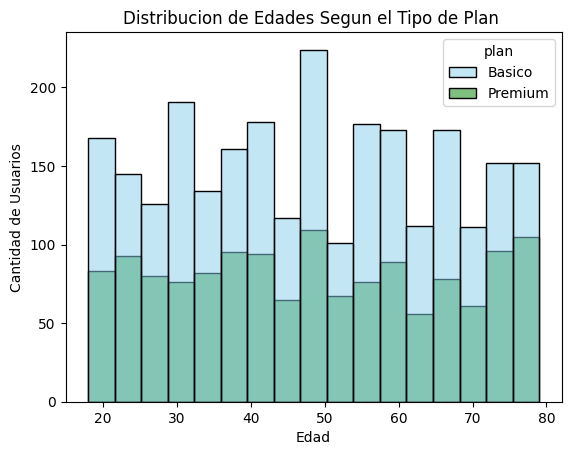

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile['age'], x=user_profile['age'], hue=user_profile['plan'], palette=['skyblue','green'])
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribucion de Edades Segun el Tipo de Plan ')
plt.show()

💡Insights:
- Distribución dispersa, hay un pico cerca de los usuarios de 47 años pero en genereal es dispersa

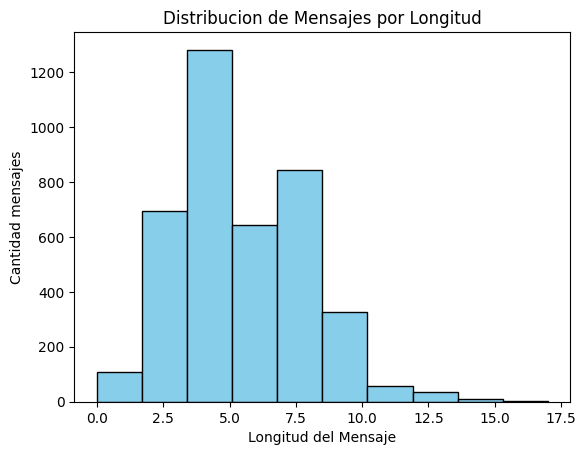

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.hist(user_profile['cant_mensajes'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Longitud del Mensaje')
plt.ylabel('Cantidad mensajes')
plt.title('Distribucion de Mensajes por Longitud')
plt.show()

💡Insights:
- La distribucion de la longitud de los mensajes tiene un sesgo a la derecha (right-skewed) donde hay pocos usuarios que enviar mensajes más largos

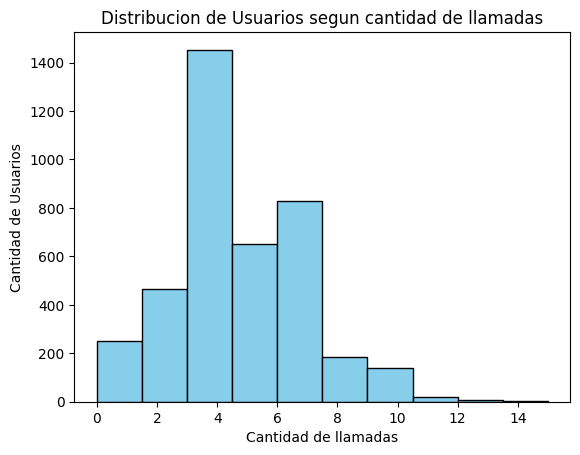

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.hist(user_profile['cant_llamadas'],bins=10,color='skyblue',edgecolor='black')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribucion de Usuarios segun cantidad de llamadas')
plt.show()

💡Insights:
- Distribución sesgada a la derecha (right-skewed) es probable que sea normal, se hará revisión para confirmar que no sean datos falsos o errores

Text(0.5, 1.0, 'Distribucion de Usuarios Segun Suracion de Llamadas')

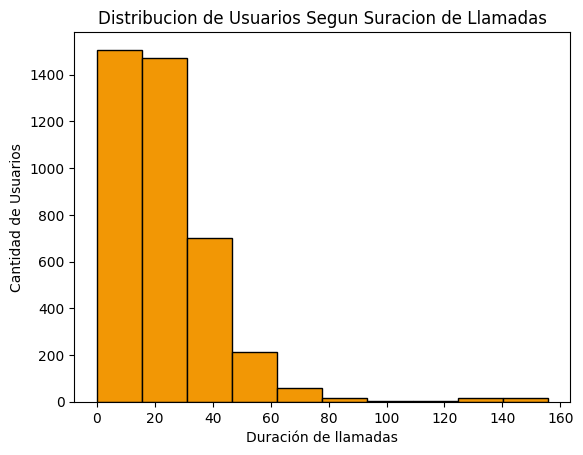

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.hist(user_profile['cant_minutos_llamada'],bins=10, color='#F29705', edgecolor='black')
plt.xlabel('Duración de llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribucion de Usuarios Segun Suracion de Llamadas')

💡Insights:
- Existe un sesgo a la derecha, la mayor cantidad de usuarios realizar llamadas cortas, existe la posibilidad de que exista un cliente whale o algun error, se validará información

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

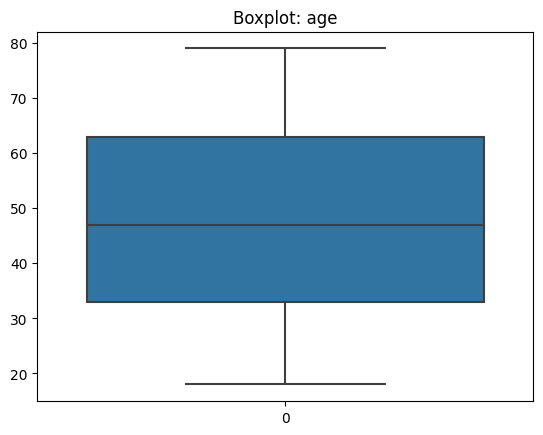

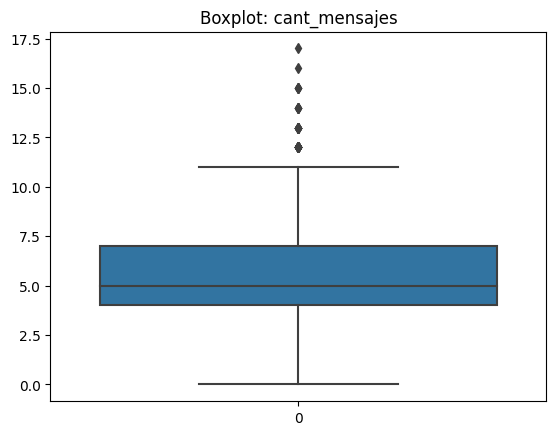

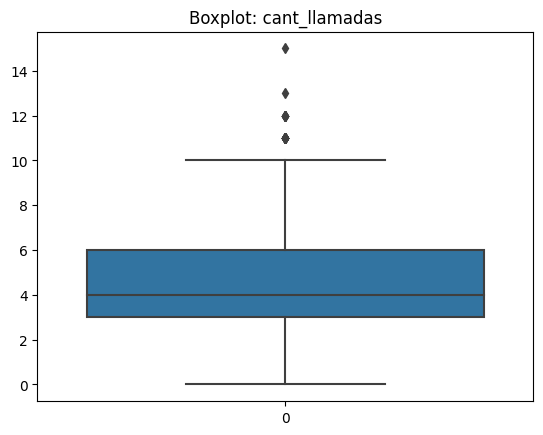

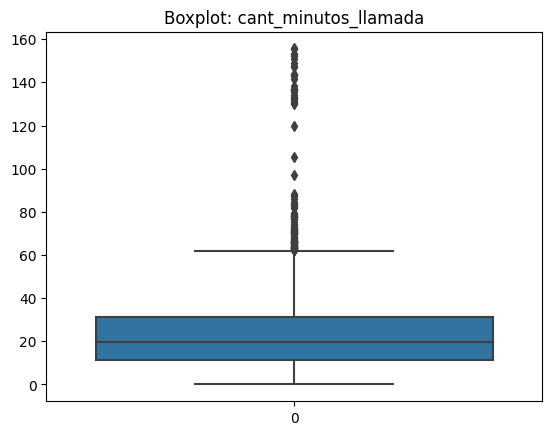

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights:
- Age: No presenta outliers (presenta o no outliers)
- cant_mensajes: Presenta pocos outliers
- cant_llamadas: Presenta pocos outliers
- cant_minutos_llamada: Presenta muchos outliers

In [ ]:


# Calcular límites con el método IQR
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
columnas_limites = []


for col in columnas_numericas:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3-Q1
    limite_inferior= Q1 - 1.5 * IQR
    limite_superior= Q3 + 1.5 * IQR
    nueva_col= f'{col}_limite'
    columnas_limites.append(nueva_col)
    user_profile[nueva_col]= user_profile[col].clip(lower=limite_inferior, upper=limite_superior)




In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age_limite,cant_mensajes_limite,cant_llamadas_limite,cant_minutos_llamada_limite
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.508377,4.470868,22.532895
std,17.690408,2.308822,2.120840,14.790722
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,11.500000,10.500000,61.857500


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Los mantendría, no existe una diferencia muy significativa en mantenerlos o no
- cant_llamadas: mantener o no outliers, porqué? Los mantendría, no existe una diferencia muy significativa en mantenerlos o no
- cant_minutos_llamada: mantener o no outliers, porqué? Los mantendría para identificar posibles clientes con gran uso del servicio lo que podría ser util para ofrecer algún servicio exclusivo

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo(row):
    llam = row['cant_llamadas']
    mens= row['cant_mensajes']


    if llam >= 10 and mens >= 10:
        return 'Alto uso'
    elif llam >= 5 and mens >= 5:
        return 'Uso medio'
    else:
        return 'Bajo uso'


user_profile['grupo_uso'] = user_profile.apply(grupo, axis=1)


In [ ]:
# verificar cambios
user_profile['grupo_uso'].isna().sum()

0

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clas_edad(row):
    age= row['age']
    if pd.isna(age):
        return 'Error'
    if age >= 60:
        return 'Adulto Mayor'
    elif age >= 30:
        return 'Adulto'
    else:
        return 'Joven'

user_profile['grupo_edad'] = user_profile.apply(clas_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamada,age_limite,cant_mensajes_limite,cant_llamadas_limite,cant_minutos_llamada_limite,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7.0,3.0,23.70,38.0,7.0,3.0,23.70,Bajo uso,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5.0,10.0,33.18,53.0,5.0,10.0,33.18,Uso medio,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5.0,2.0,10.74,57.0,5.0,2.0,10.74,Bajo uso,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11.0,3.0,8.99,69.0,11.0,3.0,8.99,Bajo uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4.0,3.0,8.01,63.0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

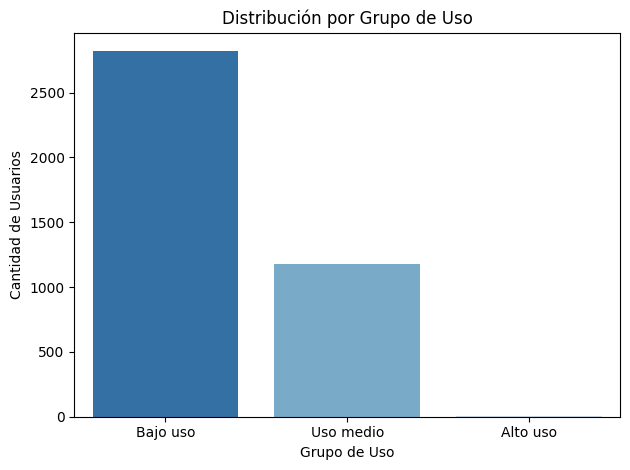

In [ ]:



sns.countplot(data=user_profile, x='grupo_uso', palette='Blues_r')
plt.title('Distribución por Grupo de Uso', fontsize=12)
plt.xlabel('Grupo de Uso', fontsize=10)
plt.ylabel('Cantidad de Usuarios', fontsize=10)

plt.tight_layout()

plt.show()

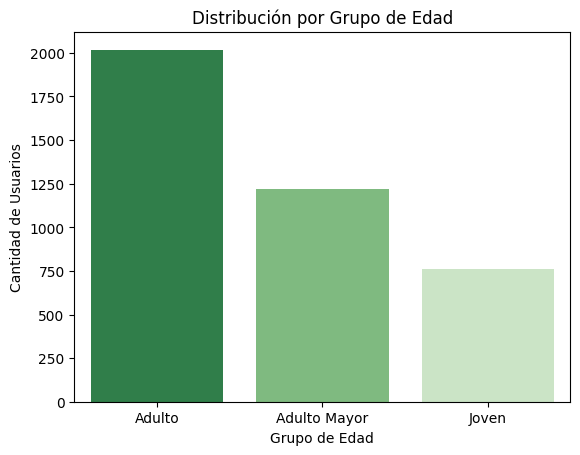

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='Greens_r')
plt.title('Distribución por Grupo de Edad', fontsize=12)
plt.xlabel('Grupo de Edad', fontsize=10)
plt.ylabel('Cantidad de Usuarios', fontsize=10)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**
Existian valores invalidos, vacios y N/A en las columnas city (11%) y age de users, length (44) y duration de usage (55)
existe una gran cantidad de usuarios de bajo uso siendo principalmente clientes de bajo uso y del grupo de edad Adulto (entre 30 y 60 años), los clientes de gasto medio representan cerca del 30% siendo en su mayoria usuarios mayores a 30 años
Mantener el trabajo realizado y pensar en compensación para los usuarios de bajo uso pues son el principal motor de la economia de la empresa y buscar posibilidades de crear un grupo de fidelización para clientes de uso medio pues utilizan con frecuencia nuestro servicio
Clientes cuyo consumo del plan es bastante grande significa una oportunidad de crear un lazo con clientes que están usando nuestro servicio

Podría recomendarse un plan adicional para clientes VIP para los clientes con mayor uso de la linea, ofreciendo un pequeño descuento al plan Premium por unos meses a clientes con plan Basico y/o algunas ventajas adicionales a clientes con plan Premium que usan bastante los servicios


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores invalidos, y vacios en la columna 'City', los cuales representaban en 11% de los datos
- También se encontraron problemas similares de valores invalidos en las columnas 'age' de users


🔍 **Segmentos por Edad**
- El grupo de edad dominante en la base de clientes de bajo uso es el Adulto entre los 30 y 60 años
- Los clientes que conforman el segmento de gasto medio son, en su mayoria usuarios mayores de 30 años


📊 **Segmentos por Nivel de Uso**
- existe una gran cantidad de usuarios de bajo uso (cerca de 2800)  quienes actualmente son el prin
- El uso medio agrupa más de 1100 clientes con un comportamiento frecuente mientras que el Alto uso se compone principalmente de valores extremos


➡️ Esto sugiere que la empresa depende criticamente de retener el volumen masivo de usuario adultos con consumo basico, pero la verdadera oportunidad de crecimiento y rentalbidad reside en incentivar a los clientes de uso medio y monetizar adecuadamente a los consumidores extremos


💡 **Recomendaciones**
- Diseñar estrategias de retencion pasiva y beneficios basicos para el gran volumen de usuarios de Bajo uso, garantizando que no migren a la competencvia
-Desarrolar una oferta VIP eclusiva para usuarios extremos y lanzar campañas con descuentos temporales para incentivar a cleintes de uso medio a migrar hacia planes premium

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`